## Pathway enrichment (ORA)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scanpy as sc
import pandas as pd
import ma_codes as codes
from ma_codes import mysize, gray_red, mymap
import pertpy as pt
import seaborn as sns
from pathlib import Path
import math
import re
import gseapy as gp

try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False

sc.settings.verbosity = 3               # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_version_and_date()

Running Scanpy 1.11.4, on 2026-08-13 11:58.


In [2]:
plt.rcParams['pdf.fonttype'] = 42

In [3]:
# Endothelial cells in endothelial compartments
dge_folder_mild   = "/media/synology/Huijuan/IPF_EC paper/snRNA_IPF_mild_severe/DGE_EC_celltype_MAST/DEG_IPF_Mild_Control/"
dge_folder_severe = "/media/synology/Huijuan/IPF_EC paper/snRNA_IPF_mild_severe/DGE_EC_celltype_MAST/DEG_IPF_Severe_Control/"

## Arterial_EC

In [5]:
cell_type_filename = "diffExpResults_Arterial_EC.xlsx"
out_base = "/media/synology/Huijuan/Plots/IPF_subsets/IPF_paper/MAST_EC_pathway/new/Arterial_EC/"

ct_label   = "Arterial EC"
ct_color   = "#95bf6b"
pval_thresh = 0.05
lfc_thresh  = 0.3
TOP_N_LABEL = 20
#GENE_SETS   = ['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020']

In [6]:
# load DGE table
def load_dge(folder, fname):
    df = pd.read_excel(Path(folder) / fname)
    df = df.rename(columns={"Unnamed: 0": "gene"})
    return df

# Get up/down regulated gene list: p<0.05, |log2FC|>0.5
def get_up_down_genes(df, pval_col="p_val", lfc_col="avg_log2FC",
                       pval_thresh=0.05, lfc_thresh=0.5):
    sub = df.dropna(subset=[pval_col, lfc_col, "gene"])
    up = sub[(sub[pval_col] < pval_thresh) & (sub[lfc_col] > lfc_thresh)]["gene"].tolist()
    down = sub[(sub[pval_col] < pval_thresh) & (sub[lfc_col] < -lfc_thresh)]["gene"].tolist()
    return up, down

# pathway enrichment
def run_enrichr_up_down(glist_up, glist_down, outdir_up, outdir_down):
    enr_up = gp.enrichr(
        gene_list=glist_up,
        organism='Human',
        gene_sets=['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020'],
        cutoff=0.05,  # p value
        outdir=outdir_up,
        no_plot=True,
    )
    enr_down = gp.enrichr(
        gene_list=glist_down,
        organism='Human',
        gene_sets=['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020'],
        cutoff=0.05,
        outdir=outdir_down,
        no_plot=True,
    )
    return enr_up, enr_down

# load enrichment result
def load_results(outdir, gene_set):
    return pd.read_csv(Path(outdir) / f"{gene_set}.Human.enrichr.reports.txt", delimiter="\t")

# ── enrichment bar plot
def make_barplot(go_df, msig_df, go_idx, msig_idx, title, savepath=None,
                  figsize=(2, 3), palette="Reds"):
    go_sel = go_df.iloc[go_idx]
    msig_sel = msig_df.iloc[msig_idx]

    selection = pd.concat([msig_sel, go_sel], axis=0)
    selection["-log10(p_adj)"] = selection["Adjusted P-value"].apply(lambda x: -math.log10(x))
    selection.sort_values(by="-log10(p_adj)", ascending=False, inplace=True)

    fig, ax = plt.subplots()
    fig.set_size_inches(*figsize)
    sns.barplot(
        selection, x="-log10(p_adj)", y="Term", orient="y",
        hue="Gene_set", palette=palette,
        hue_order=["GO_Biological_Process_2025", "MSigDB_Hallmark_2020"]
    )
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.title(title, loc='center')
    if savepath:
        plt.savefig(savepath, bbox_inches="tight")
    return fig, selection

# ── volcano plot ───────────────────────────────────────────────────────────────
def plot_volcano(
    df,
    condition,
    savepath=None,
    save=True,
    show=True,
    pval_col="p_val",
    lfc_col="avg_log2FC",
    figsize=(5, 4.5)
):
    df = df.dropna(subset=[pval_col, lfc_col, "gene"]).copy()

    df["-log10p"] = -np.log10(df[pval_col].clip(lower=1e-300))

    def status(r):
        if r[pval_col] < pval_thresh and r[lfc_col] > lfc_thresh:
            return "up"
        if r[pval_col] < pval_thresh and r[lfc_col] < -lfc_thresh:
            return "down"
        return "ns"

    df["status"] = df.apply(status, axis=1)

    n_up = (df["status"] == "up").sum()
    n_down = (df["status"] == "down").sum()

    color_map = {"up": ct_color, "down": "#4477AA", "ns": "#cccccc"}
    size_map = {"up": 18, "down": 18, "ns": 4}
    alpha_map = {"up": 0.85, "down": 0.85, "ns": 0.3}

    fig, ax = plt.subplots(figsize=figsize)

    for s in ["ns", "down", "up"]:
        sub = df[df["status"] == s]

        ax.scatter(
            sub[lfc_col],
            sub["-log10p"],
            s=size_map[s],
            c=color_map[s],
            alpha=alpha_map[s],
            linewidths=0,
            zorder=1 if s == "ns" else 3,
            rasterized=(s == "ns"),
        )

    ax.axhline(-np.log10(pval_thresh), color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(lfc_thresh, color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(-lfc_thresh, color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(0, color="#444444", lw=0.5, ls="-", zorder=2)

    top = pd.concat([
        df[df["status"] == "up"].nlargest(TOP_N_LABEL, "-log10p"),
        df[df["status"] == "down"].nlargest(TOP_N_LABEL, "-log10p"),
    ])

    texts = [
        ax.text(
            r[lfc_col],
            r["-log10p"],
            r["gene"],
            fontsize=6.5,
            color="#222222",
        )
        for _, r in top.iterrows()
    ]

    if HAS_ADJUSTTEXT:
        adjust_text(
            texts,
            ax=ax,
            arrowprops=dict(arrowstyle="-", color="#aaaaaa", lw=0.5),
        )

    xlim, ylim = ax.get_xlim(), ax.get_ylim()

    ax.text(
        xlim[1] * 0.97,
        ylim[1] * 0.97,
        f"Up: {n_up}",
        ha="right",
        va="top",
        fontsize=8,
        color=ct_color,
        fontweight="bold",
    )

    ax.text(
        xlim[0] * 0.97,
        ylim[1] * 0.97,
        f"Down: {n_down}",
        ha="left",
        va="top",
        fontsize=8,
        color="#4477AA",
        fontweight="bold",
    )

    ax.set_xlabel("log2 Fold Change", fontsize=10)
    ax.set_ylabel("–log10(p value)", fontsize=10)

    ax.set_title(
        f"{ct_label} — {condition}\n"
        f"threshold: p < {pval_thresh}, |log2FC| > {lfc_thresh}",
        fontsize=9,
        fontweight="bold",
    )

    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

    plt.tight_layout()

    if save:
        if savepath is None:
            raise ValueError("savepath must be provided when save=True")

        plt.savefig(savepath, bbox_inches="tight", dpi=300)
        print(f"  Saved: {Path(savepath).name}")

    if show:
        plt.show()

    plt.close(fig)

## Mild vs control

In [7]:
df_mild = load_dge(dge_folder_mild, cell_type_filename)
df_mild.head()

,gene,entrezgene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,mean_IPF_Mild,mean_Control
0,PLXDC2,84898.0,5.489215e-20,-1.403393,0.355,0.790,1.708518e-15,1.039232,1.764676
1,NAV3,89795.0,7.308794e-16,-2.992629,0.107,0.524,2.274862e-11,0.226910,1.115402
2,ATP13A3,79572.0,3.132328e-15,2.178363,0.585,0.302,9.749371e-11,1.435384,0.534356
3,XIST,7503.0,3.480647e-15,-0.721082,0.223,0.322,1.083351e-10,0.369175,0.553703
4,SPDYA,245711.0,2.825025e-13,0.192776,0.025,0.037,8.792889e-09,0.043084,0.038915


In [8]:
glist_mild_up, glist_mild_down = get_up_down_genes(df_mild, pval_thresh=pval_thresh, lfc_thresh=lfc_thresh)
print(f"Mild vs Control DEGs— up: {len(glist_mild_up)}, down: {len(glist_mild_down)}")

Mild vs Control DEGs— up: 1176, down: 248


In [9]:
print(glist_mild_up)

['ATP13A3', 'LDB2', 'ENG', 'PITPNC1', 'GSE1', 'SLCO2A1', 'MAST4', 'ARAP3', 'SMAD6', 'KLF13', 'RAPGEF5', 'ADAMTS6', 'PCSK5', 'PLGRKT', 'NAV1', 'AL353138.1', 'EMP1', 'GRK5', 'MCM3', 'ZFYVE28', 'DHH', 'MT2A', 'FENDRR', 'SGK1', 'SMG5', 'SECISBP2L', 'RAPGEF1', 'SMURF2', 'AHR', 'VASH1', 'ARHGAP4', 'PREX1', 'RFC3', 'EXOC6', 'SLC15A3', 'MT1E', 'PTCHD4', 'AZIN1', 'SH3RF3', 'EPHB4', 'LDLRAP1', 'UTY', 'MFSD12', 'ZNF276', 'ZNF490', 'NPC2', 'SLC35C2', 'NDUFAF7', 'ZFHX3', 'ADCY4', 'KLF4', 'ELN', 'EPB41L4A', 'KPNA3', 'PTPRJ', 'MGAT4A', 'PPIE', 'CSMD1', 'GSR', 'ATP5F1A', 'PECAM1', 'IPO9-AS1', 'ARL10', 'NPDC1', 'PBRM1', 'PTCD1', 'SLC7A6', 'SPDYE2', 'PDE4D', 'FUT8', 'ZNF467', 'SLC11A2', 'SSTR1', 'TMCC3', 'XRRA1', 'PRICKLE2', 'MAST2', 'AKAP13', 'PALB2', 'CDC40', 'TXN2', 'AC026356.2', 'EVI5', 'SSH2', 'ALG8', 'ITGA6', 'ACE', 'CFAP54', 'M6PR', 'FBXO38', 'ARHGAP15', 'TET3', 'CUEDC1', 'MTCH1', 'IDO2', 'NCKAP5', 'ILF2', 'LINC01320', 'VWF', 'PLPP3', 'PIK3R3', 'SRPRA', 'AL499616.1', 'ACACA', 'PDE10A', 'CTIF', 'S

  Saved: volcano_Arterial_EC_mild_vs_control.pdf


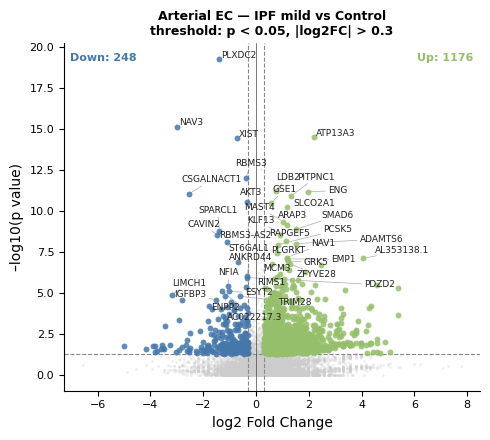

In [10]:
plot_volcano(df_mild, "IPF mild vs Control", save =True, show = True,
             savepath=out_base +"volcano_Arterial_EC_mild_vs_control.pdf")

In [11]:
enr_mild_up, enr_mild_down = run_enrichr_up_down(
    glist_mild_up, glist_mild_down,
    outdir_up=f"{out_base}/mild_up",
    outdir_down=f"{out_base}/mild_down",
)

### Upregulated pythways

In [12]:
GO_mild_up   = load_results(f"{out_base}/mild_up", "GO_Biological_Process_2025")
GO_mild_up.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Positive Regulation of Extracellular Matrix As...,7/11,6.392671e-07,0.002068,0,0,28.173650,401.83920,PHLDB1;SMAD4;RGCC;SMAD3;TGFB1;DAG1;TGFBR1
1,GO_Biological_Process_2025,Negative Regulation of Growth (GO:0045926),19/115,3.969122e-05,0.052768,0,0,3.203616,32.46666,SMAD4;SMAD3;TGFB1;BMPR2;NPR1;MT1M;WFDC1;PTPRJ;...
2,GO_Biological_Process_2025,Negative Regulation of Receptor Internalizatio...,6/13,4.893448e-05,0.052768,0,0,13.785350,136.82000,MTMR2;ATXN2;ANKRD13D;ANXA2;RIN3;WDR54
3,GO_Biological_Process_2025,Positive Regulation of Extracellular Matrix Or...,7/21,1.337537e-04,0.088586,0,0,8.045338,71.76048,SMAD4;EFEMP2;SMAD3;TGFB1;RGCC;IER3IP1;TGFBR1
4,GO_Biological_Process_2025,Regulation of Extracellular Matrix Assembly (G...,5/10,1.369179e-04,0.088586,0,0,16.070880,142.96860,SMAD4;RGCC;SMAD3;TGFB1;TGFBR1
5,GO_Biological_Process_2025,Artery Development (GO:0060840),7/23,2.542267e-04,0.137071,0,0,7.038922,58.26316,EFEMP2;BMPR2;HECTD1;SLC2A10;GJA5;TGFBR1;ENG
6,GO_Biological_Process_2025,Hippo Signaling (GO:0035329),6/20,7.741608e-04,0.357773,0,0,6.890110,49.35889,YAP1;LATS1;WWTR1;WWC2;WWC3;FAT4
7,GO_Biological_Process_2025,Regulation of Intracellular Protein Transport ...,8/38,1.402902e-03,0.418331,0,0,4.290868,28.18762,RIPOR1;TGFB1;IFI27;B3GAT3;PCNT;OAZ1;PTPN14;SEP...
8,GO_Biological_Process_2025,Regulation of Notch Signaling Pathway (GO:0008...,12/76,1.523216e-03,0.418331,0,0,3.021907,19.60291,JAG2;GALNT11;POGLUT1;JAG1;YTHDF2;MFNG;ARRB1;NR...
9,GO_Biological_Process_2025,Small GTPase-mediated Signal Transduction (GO:...,22/188,1.616163e-03,0.418331,0,0,2.142762,13.77303,CYFIP1;RIPOR1;RALA;SIAH2;RASGRF2;ARHGAP15;NTN1...


In [13]:
Msig_mild_up = load_results(f"{out_base}/mild_up", "MSigDB_Hallmark_2020")
Msig_mild_up.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,TGF-beta Signaling,15/54,3.135570e-07,0.000016,0,0,6.223084,93.192450,CDKN1C;BCAR3;ACVR1;WWTR1;BMPR2;TGFB1;SMAD3;SMU...
1,MSigDB_Hallmark_2020,Mitotic Spindle,25/199,2.785715e-04,0.006964,0,0,2.328061,19.057120,TUBGCP2;RASAL2;SMC3;BRCA2;ARHGAP4;PREX1;AKAP13...
2,MSigDB_Hallmark_2020,PI3K/AKT/mTOR Signaling,13/105,8.579080e-03,0.142985,0,0,2.275936,10.829880,ATF1;MAP2K3;PRKAG1;PIK3R3;IRAK4;ACACA;PRKAR2A;...
3,MSigDB_Hallmark_2020,Complement,20/200,1.430368e-02,0.178796,0,0,1.792003,7.611064,C1S;C1R;KCNIP3;PRKCD;PREP;PLAUR;GATA3;LIPA;GNA...
4,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,19/200,2.685765e-02,0.223814,0,0,1.691443,6.118297,STAT5A;MAP2K3;JAG1;SMAD3;GADD45B;PLAUR;CFLAR;K...
5,MSigDB_Hallmark_2020,Apical Junction,19/200,2.685765e-02,0.223814,0,0,1.691443,6.118297,VWF;ITGB4;ITGA2;PIK3R3;TUBG1;MPP5;MAPK14;MYL12...
6,MSigDB_Hallmark_2020,Androgen Response,11/100,3.284832e-02,0.234631,0,0,1.987607,6.789376,SLC26A2;CCND1;TMEM50A;ELOVL5;ABHD2;SELENOP;GSR...
7,MSigDB_Hallmark_2020,mTORC1 Signaling,18/200,4.795711e-02,0.299732,0,0,1.592154,4.836085,MAP2K3;FKBP2;NUFIP1;PSMD14;ELOVL5;TXNRD1;GSR;M...
8,MSigDB_Hallmark_2020,Reactive Oxygen Species Pathway,6/49,6.620741e-02,0.314721,0,0,2.239833,6.081064,ABCC1;GCLC;PRDX4;FES;TXNRD1;GSR
9,MSigDB_Hallmark_2020,Estrogen Response Early,17/200,8.133835e-02,0.314721,0,0,1.494114,3.748937,SLC26A2;SLC37A1;TGIF2;MAST4;ELOVL5;SIAH2;ABHD2...


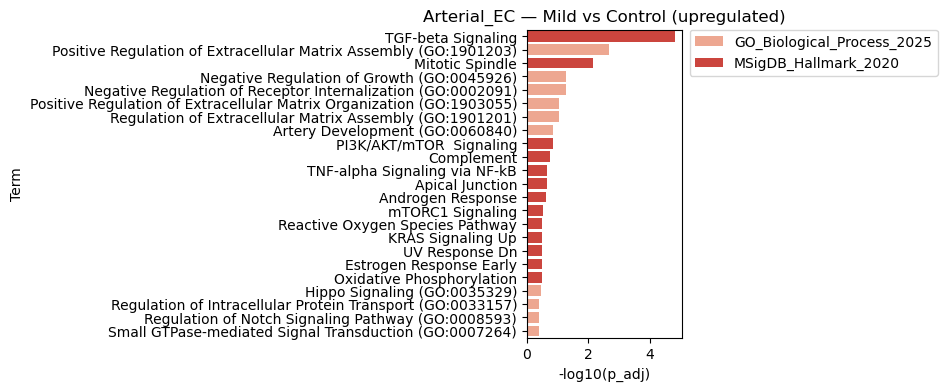

In [14]:
fig_mild_up, sel_mild_up = make_barplot(
    GO_mild_up, Msig_mild_up,
    go_idx=range(0, 10), msig_idx=range(0, 13),
    title="Arterial_EC — Mild vs Control (upregulated)",
    savepath=f"{out_base}/Arterial_EC_mild_up.pdf",
    figsize=(2, 4)
)

### Downregulated pathways

In [15]:
GO_mild_down   = load_results(f"{out_base}/mild_down", "GO_Biological_Process_2025")
GO_mild_down.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Negative Regulation of Cell Motility (GO:2000146),10/139,0.000009,0.014375,0,0,6.391440,73.96422,TGFBR3;EPHA4;DACH1;PDZD2;NAV3;LIMCH1;SERPINE1;...
1,GO_Biological_Process_2025,Negative Regulation of Cell Migration (GO:0030...,11/184,0.000020,0.014375,0,0,5.252774,56.93986,TGFBR3;EPHA4;DACH1;NAV3;LIMCH1;IGFBP3;SERPINE1...
2,GO_Biological_Process_2025,Regulation of Cell Migration (GO:0030334),18/479,0.000032,0.014375,0,0,3.274903,33.86411,EPHA4;LIMCH1;ANKRD44;SERPINE1;NEDD9;LDLRAD4;SU...
3,GO_Biological_Process_2025,Positive Regulation of Lamellipodium Morphogen...,3/6,0.000037,0.014375,0,0,80.608160,823.34470,ENPP2;RREB1;CORO1C
4,GO_Biological_Process_2025,Negative Regulation of SMAD Protein Signal Tra...,4/22,0.000142,0.044429,0,0,17.972680,159.28490,TGFBR3;PDZD2;PPARG;LDLRAD4
5,GO_Biological_Process_2025,Regulation of Lamellipodium Morphogenesis (GO:...,3/10,0.000212,0.055422,0,0,34.539360,292.17580,ENPP2;RREB1;CORO1C
6,GO_Biological_Process_2025,Defense Response to Tumor Cell (GO:0002357),3/11,0.000289,0.061897,0,0,30.220410,246.29490,DAPK1;TNFRSF10B;RBMS3
7,GO_Biological_Process_2025,Regulation of Protein Phosphorylation (GO:0001...,8/137,0.000316,0.061897,0,0,5.070543,40.87380,TSPYL2;PDZD2;LIMCH1;IGFBP3;ATG14;C9ORF72;FNIP2...
8,GO_Biological_Process_2025,Negative Regulation of Protein Phosphorylation...,6/83,0.000582,0.097230,0,0,6.335194,47.19026,ERRFI1;IGFBP3;PARD3;ATG14;C9ORF72;CORO1C
9,GO_Biological_Process_2025,Lipoprotein Transport (GO:0042953),3/14,0.000620,0.097230,0,0,21.975140,162.31460,PPARG;PREB;CD36


In [16]:
Msig_mild_down = load_results(f"{out_base}/mild_down", "MSigDB_Hallmark_2020")
Msig_mild_down.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,Hypoxia,12/200,0.000008,0.000332,0,0,5.291381,62.157450,PPP1R15A;ERRFI1;JUN;TIPARP;IGFBP3;SERPINE1;MAF...
1,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,11/200,0.000042,0.000888,0,0,4.804166,48.384680,PPP1R15A;JUN;TIPARP;SERPINE1;MAFF;KLF9;TNFAIP3...
2,MSigDB_Hallmark_2020,UV Response Dn,9/144,0.000080,0.001116,0,0,5.471967,51.641000,TGFBR3;TJP1;SERPINE1;AKT3;ATRX;PPARG;KALRN;RND...
3,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,10/200,0.000206,0.002161,0,0,4.325962,36.721900,TGFBR3;JUN;LAMA2;ABI3BP;IGFBP3;TPM2;SERPINE1;T...
4,MSigDB_Hallmark_2020,Adipogenesis,8/200,0.003583,0.030101,0,0,3.395833,19.123450,CAVIN2;UBC;ENPP2;SPARCL1;PREB;PPARG;CD36;RREB1
5,MSigDB_Hallmark_2020,Fatty Acid Metabolism,6/158,0.014103,0.098719,0,0,3.197042,13.623830,HMGCL;AUH;XIST;CD36;HSD17B11;GLUL
6,MSigDB_Hallmark_2020,TGF-beta Signaling,3/54,0.029390,0.176340,0,0,4.730132,16.683660,PPP1R15A;TJP1;SERPINE1
7,MSigDB_Hallmark_2020,Estrogen Response Early,6/200,0.038853,0.181314,0,0,2.499531,8.118402,SEC14L2;PDLIM3;TIPARP;MYOF;THSD4;IGF1R
8,MSigDB_Hallmark_2020,KRAS Signaling Up,6/200,0.038853,0.181314,0,0,2.499531,8.118402,BTC;PPP1R15A;ST6GAL1;IGFBP3;SPARCL1;TNFAIP3
9,MSigDB_Hallmark_2020,Apoptosis,5/161,0.050482,0.212024,0,0,2.584679,7.718218,TGFBR3;JUN;NEDD9;ATF3;MCL1


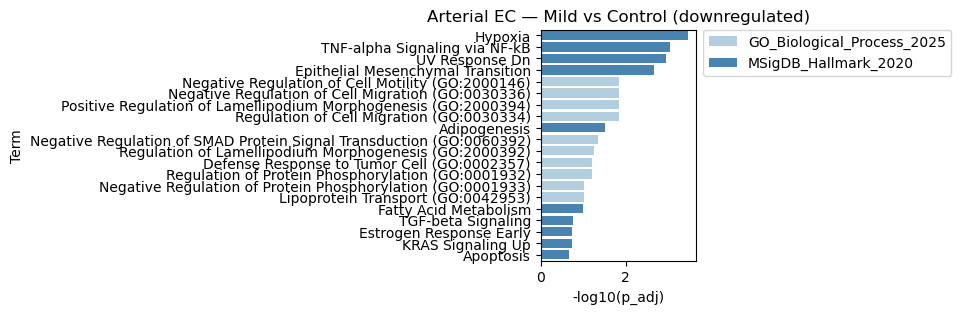

In [17]:
fig_mild_down, sel_mild_down = make_barplot(
    GO_mild_down, Msig_mild_down,
    go_idx=range(0, 10), msig_idx=range(0, 10),
    title="Arterial EC — Mild vs Control (downregulated)",
    savepath=f"{out_base}/Arterial_EC_mild_down.pdf",
    palette="Blues",
)

## Severe vs control

In [18]:
df_severe = load_dge(dge_folder_severe, cell_type_filename)
df_severe.head()

,gene,entrezgene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,mean_IPF_Severe,mean_Control
0,LTBP1,4052.0,3.081994e-19,2.022439,0.580,0.373,9.592705e-15,1.622123,0.693147
1,PDE4D,5144.0,1.771535e-14,0.414989,0.426,0.360,5.513903e-10,1.157149,0.970057
2,XIST,7503.0,2.499964e-14,-0.568071,0.218,0.322,7.781139e-10,0.401913,0.553703
3,SIPA1L2,57568.0,4.672311e-14,2.070847,0.410,0.156,1.454257e-09,0.635676,0.191538
4,RFC3,5983.0,9.070149e-12,2.196687,0.335,0.137,2.823084e-07,0.644091,0.179673


In [19]:
glist_severe_up, glist_severe_down = get_up_down_genes(df_severe, pval_thresh=pval_thresh, lfc_thresh=lfc_thresh)
print(f"Severe vs Control DEGs— up: {len(glist_severe_up)}, down: {len(glist_severe_down)}")

Severe vs Control DEGs— up: 953, down: 182


In [20]:
print(glist_severe_up)

['LTBP1', 'PDE4D', 'SIPA1L2', 'RFC3', 'ENG', 'ADAMTS6', 'PLCB1', 'MAST4', 'ADAMTS1', 'FUT8', 'PIK3R3', 'MCTP1', 'RAPGEF5', 'TANC2', 'ATP13A3', 'RFK', 'COL21A1', 'SMAD6', 'ANGEL1', 'POLR3E', 'FBLN5', 'SHANK3', 'SLC8A1', 'ZFYVE28', 'ZNF276', 'KLF12', 'MECOM', 'AIF1L', 'GFOD1', 'DKK2', 'FKBP1A', 'GRAMD4', 'RAPGEF4', 'FAM221A', 'EXOC6', 'SLC15A3', 'UBAP2', 'RFTN1', 'EDEM2', 'ZMIZ2', 'PECAM1', 'LINC01695', 'DISP1', 'NALCN-AS1', 'AC026356.2', 'ASRGL1', 'PALB2', 'ARL17B', 'KLF3', 'FAM222A', 'SH3PXD2B', 'NLGN1', 'LDB2', 'ZNF75A', 'SHE', 'ATG14', 'DST', 'DISC1', 'HMGCL', 'AKAP13', 'CYYR1', 'PREX2', 'IL27RA', 'TSPAN9', 'MGAT4A', 'RASGRF2', 'HACE1', 'UQCR11', 'MERTK', 'TMEM87B', 'PIK3C2B', 'PDS5A', 'CMIP', 'DGKZ', 'SMAD9', 'PREX1', 'HECW2', 'DESI1', 'AL033543.1', 'PSORS1C1', 'PLCB4', 'EGFL7', 'CD93', 'NAV1', 'CTTNBP2NL', 'EMP1', 'AL590226.1', 'BMPER', 'KDM6A', 'NOVA2', 'AP1G2', 'WWTR1', 'AVEN', 'NAMPT', 'SRPX', 'CPNE5', 'CHL1', 'SUPT7L', 'PCDH17', 'JAG2', 'MGST2', 'SLC19A3', 'NEDD8', 'STOM', 'THS

  Saved: volcano_Arterial_EC_severe_vs_control.pdf


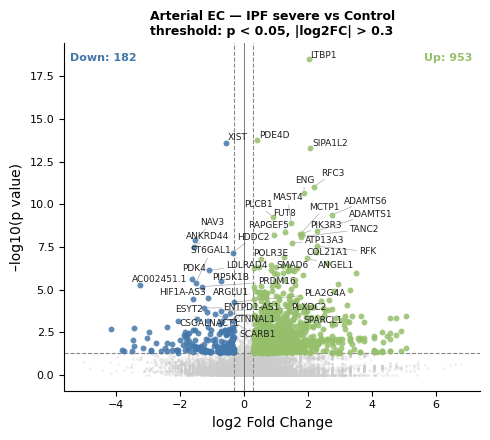

In [21]:
plot_volcano(df_severe, "IPF severe vs Control", save =True, show = True,
             savepath=out_base +"volcano_Arterial_EC_severe_vs_control.pdf")

In [22]:
enr_severe_up, enr_severe_down = run_enrichr_up_down(
    glist_severe_up, glist_severe_down,
    outdir_up=f"{out_base}/severe_up",
    outdir_down=f"{out_base}/severe_down",
)

### Upregulated pathways

In [23]:
GO_severe_up   = load_results(f"{out_base}/severe_up", "GO_Biological_Process_2025")
GO_severe_up.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Regulation of Postsynapse Organization (GO:009...,8/32,0.000098,0.167542,0,0,6.710053,61.96198,APP;TANC1;HOMER1;ABHD17B;ABHD17C;PDLIM5;SHANK3...
1,GO_Biological_Process_2025,Regulation of G Protein-Coupled Receptor Signa...,12/72,0.000140,0.167542,0,0,4.035494,35.81419,KCTD8;APP;RGS5;GIT2;RGS3;RAMP3;RIC8B;GRK5;DTNB...
2,GO_Biological_Process_2025,Positive Regulation of Cardiac Epithelial to M...,4/7,0.000160,0.167542,0,0,26.756590,233.90920,NOTCH1;TGFBR1;ENG;TGFBR2
3,GO_Biological_Process_2025,Positive Regulation of Cell Differentiation (G...,28/297,0.000478,0.258006,0,0,2.113067,16.15821,APP;GSK3B;LEF1;LAMC1;ATRAID;TMEM100;BLOC1S5;ZF...
4,GO_Biological_Process_2025,Regulation of Signal Transduction (GO:0009966),22/211,0.000488,0.258006,0,0,2.357799,17.97680,APP;GIT2;GALNT11;HOMER1;IGFBP5;DTNBP1;FBXL17;A...
5,GO_Biological_Process_2025,Ubiquitin-Dependent Protein Catabolic Process ...,38/455,0.000594,0.258006,0,0,1.855407,13.78268,GSK3B;RNF34;UBE2D2;CUL1;NEDD8;AGAP3;AMBRA1;RNF...
6,GO_Biological_Process_2025,Regulation of Extracellular Matrix Assembly (G...,4/10,0.000854,0.258006,0,0,13.376190,94.51205,NOTCH1;RGCC;SMAD3;TGFBR1
7,GO_Biological_Process_2025,Response to Laminar Fluid Shear Stress (GO:003...,4/10,0.000854,0.258006,0,0,13.376190,94.51205,KLF4;SMAD6;ASS1;NFE2L2
8,GO_Biological_Process_2025,Cell Surface Receptor Protein Serine/Threonine...,6/25,0.000935,0.258006,0,0,6.345134,44.25672,WWTR1;SMAD3;ZMIZ2;SMAD9;SMAD6;ACVR2B
9,GO_Biological_Process_2025,Synaptic Vesicle Recycling (GO:0036465),7/34,0.000948,0.258006,0,0,5.212591,36.28635,AP3M2;GIT2;OPHN1;SYNJ1;CANX;SYNJ2;AP2M1


In [24]:
Msig_severe_up = load_results(f"{out_base}/severe_up", "MSigDB_Hallmark_2020")
Msig_severe_up.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,UV Response Dn,25/144,1.863391e-08,9.130614e-07,0,0,4.284990,76.26546,INSIG1;PIK3R3;LAMC1;LTBP1;SLC7A1;FBLN5;SYNE1;G...
1,MSigDB_Hallmark_2020,Mitotic Spindle,20/199,1.358561e-03,3.328474e-02,0,0,2.259546,14.91601,PLEKHG2;DST;ARAP3;SMC4;LRPPRC;LMNB1;BCR;PREX1;...
2,MSigDB_Hallmark_2020,Reactive Oxygen Species Pathway,8/49,2.045779e-03,3.341440e-02,0,0,3.924326,24.29933,PDLIM1;NQO1;ABCC1;NDUFA6;GPX3;FES;GSR;HMOX2
3,MSigDB_Hallmark_2020,TGF-beta Signaling,8/54,3.829658e-03,4.001563e-02,0,0,3.496848,19.45989,FKBP1A;WWTR1;SMAD3;ID1;ID3;SMAD6;TGFBR1;ENG
4,MSigDB_Hallmark_2020,Apical Surface,7/44,4.467854e-03,4.001563e-02,0,0,3.801783,20.57086,SRPX;APP;AFAP1L2;CROCC;ADIPOR2;EPHB4;SULF2
5,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,18/200,7.349810e-03,4.001563e-02,0,0,1.995475,9.80393,SMAD3;GADD45B;GCH1;ATP2B1;KLF4;NFKB1;FOSL2;EIF...
6,MSigDB_Hallmark_2020,Apical Junction,18/200,7.349810e-03,4.001563e-02,0,0,1.995475,9.80393,CAP1;NLGN2;VWF;INSIG1;PIK3R3;GNAI2;CLDN5;CDK8;...
7,MSigDB_Hallmark_2020,mTORC1 Signaling,18/200,7.349810e-03,4.001563e-02,0,0,1.995475,9.80393,GSK3B;EGLN3;TES;IGFBP5;ELOVL5;INSIG1;GSR;FGL2;...
8,MSigDB_Hallmark_2020,p53 Pathway,18/200,7.349810e-03,4.001563e-02,0,0,1.995475,9.80393,JAG2;APP;NOTCH1;FUCA1;PVT1;CGRRF1;PPM1D;KLF4;P...
9,MSigDB_Hallmark_2020,Pperoxisome,11/104,1.066482e-02,5.225763e-02,0,0,2.379905,10.80669,FDPS;HMGCL;CDK7;ERCC3;ELOVL5;EHHADH;MVP;NUDT19...


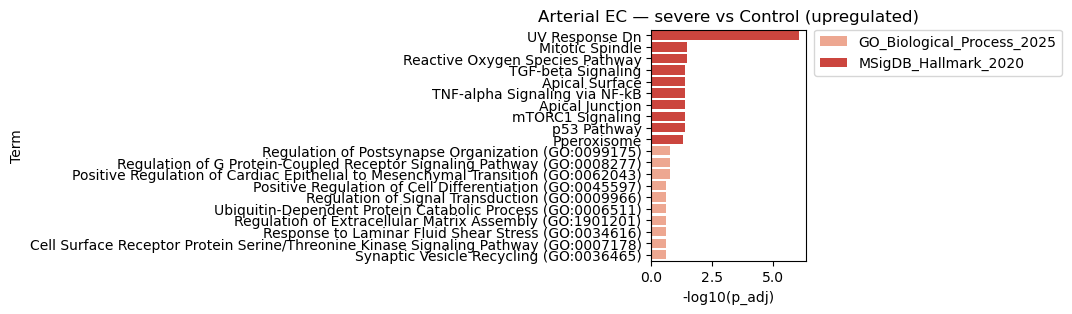

In [25]:
fig_severe_up, sel_severe_up = make_barplot(
    GO_severe_up, Msig_severe_up,
    go_idx=range(0, 10), msig_idx=range(0, 10),
    title="Arterial EC — severe vs Control (upregulated)",
    savepath=f"{out_base}/Arterial_EC_severe_up.pdf",
)

### Downregulated pathways

In [26]:
GO_severe_down   = load_results(f"{out_base}/severe_down", "GO_Biological_Process_2025")
GO_severe_down.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Carboxylic Acid Metabolic Process (GO:0019752),4/36,0.000311,0.190185,0,0,13.894660,112.19830,CSGALNACT1;ST6GAL1;PTGIS;PLA2G4A
1,GO_Biological_Process_2025,Regulation of Stress Fiber Assembly (GO:0051492),5/75,0.000609,0.190185,0,0,7.969330,59.00150,TJP1;LIMCH1;TPM1;ARHGAP6;CGNL1
2,GO_Biological_Process_2025,Positive Regulation of Wound Healing (GO:0090303),4/44,0.000678,0.190185,0,0,11.111240,81.07484,OCLN;SERPINE1;ST3GAL4;RREB1
3,GO_Biological_Process_2025,Regulation of Blood-Brain Barrier Permeability...,2/6,0.001206,0.190185,0,0,55.038890,369.88570,TJP1;OCLN
4,GO_Biological_Process_2025,Negative Regulation of Stress Fiber Assembly (...,3/24,0.001303,0.190185,0,0,15.799680,104.95590,TJP1;ARHGAP6;CGNL1
5,GO_Biological_Process_2025,Small GTPase-mediated Signal Transduction (GO:...,7/188,0.001703,0.190185,0,0,4.339669,27.66745,RASGEF1B;NCOA3;ARHGEF3;PLCE1;ARHGAP18;ARHGAP6;...
6,GO_Biological_Process_2025,Negative Regulation of Cell Motility (GO:2000146),6/139,0.001729,0.190185,0,0,5.045711,32.09103,DACH1;NAV3;LIMCH1;SERPINE1;TPM1;LDLRAD4
7,GO_Biological_Process_2025,Negative Regulation of Actin Filament Bundle A...,3/27,0.001846,0.190185,0,0,13.822630,87.00947,TJP1;ARHGAP6;CGNL1
8,GO_Biological_Process_2025,Amino Sugar Metabolic Process (GO:0006040),2/8,0.002224,0.190185,0,0,36.688890,224.10610,CSGALNACT1;ST6GAL1
9,GO_Biological_Process_2025,Protein Localization to Cell Junction (GO:1902...,3/29,0.002276,0.190185,0,0,12.758060,77.63939,TJP1;MPP3;CGNL1


In [27]:
Msig_severe_down = load_results(f"{out_base}/severe_down", "MSigDB_Hallmark_2020")
Msig_severe_down.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,TGF-beta Signaling,4/54,0.001471,0.033005,0,0,8.884494,57.940640,PPP1R15A;TJP1;SERPINE1;PMEPA1
1,MSigDB_Hallmark_2020,UV Response Dn,6/144,0.002068,0.033005,0,0,4.861660,30.051680,TJP1;MTA1;SERPINE1;GCNT1;KALRN;RND3
2,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,7/200,0.002415,0.033005,0,0,4.067358,24.510180,JUN;ITGB5;LAMA2;SERPINE1;TPM1;PMEPA1;FSTL1
3,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,6/200,0.010103,0.069037,0,0,3.448454,15.845390,PPP1R15A;JUN;BTG1;SERPINE1;PMEPA1;ATF3
4,MSigDB_Hallmark_2020,Hypoxia,6/200,0.010103,0.069037,0,0,3.448454,15.845390,PPP1R15A;SCARB1;JUN;BTG1;SERPINE1;ATF3
5,MSigDB_Hallmark_2020,Interferon Gamma Response,6/200,0.010103,0.069037,0,0,3.448454,15.845390,PSMA3;BTG1;CASP8;NCOA3;PLA2G4A;IRF9
6,MSigDB_Hallmark_2020,Hedgehog Signaling,2/36,0.042389,0.248276,0,0,6.465359,20.436210,TLE1;DPYSL2
7,MSigDB_Hallmark_2020,Fatty Acid Metabolism,4/158,0.056511,0.267749,0,0,2.869400,8.244702,GABARAPL1;AUH;HPGD;XIST
8,MSigDB_Hallmark_2020,Interferon Alpha Response,3/97,0.058774,0.267749,0,0,3.516700,9.966517,PSMA3;CASP8;IRF9
9,MSigDB_Hallmark_2020,Unfolded Protein Response,3/113,0.084212,0.322399,0,0,3.002743,7.430044,NABP1;MTREX;ATF3


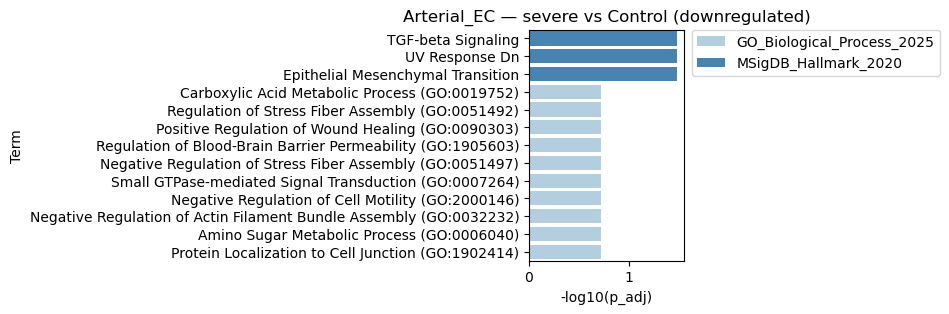

In [28]:
fig_severe_down, sel_severe_down = make_barplot(
    GO_severe_down, Msig_severe_down,
    go_idx=range(0, 10), msig_idx=range(0, 3),
    title="Arterial_EC — severe vs Control (downregulated)",
    savepath=f"{out_base}/Arterial_EC_severe_down.pdf",
    palette="Blues",
)

In [29]:
print(f"Mild vs Control — up: {len(glist_mild_up)}, down: {len(glist_mild_down)}")
print(f"Severe vs Control — up: {len(glist_severe_up)}, down: {len(glist_severe_down)}")

Mild vs Control — up: 1176, down: 248
Severe vs Control — up: 953, down: 182


In [30]:
print("Upregulated genes (Mild vs Control):")
print(glist_mild_up)

Upregulated genes (Mild vs Control):
['ATP13A3', 'LDB2', 'ENG', 'PITPNC1', 'GSE1', 'SLCO2A1', 'MAST4', 'ARAP3', 'SMAD6', 'KLF13', 'RAPGEF5', 'ADAMTS6', 'PCSK5', 'PLGRKT', 'NAV1', 'AL353138.1', 'EMP1', 'GRK5', 'MCM3', 'ZFYVE28', 'DHH', 'MT2A', 'FENDRR', 'SGK1', 'SMG5', 'SECISBP2L', 'RAPGEF1', 'SMURF2', 'AHR', 'VASH1', 'ARHGAP4', 'PREX1', 'RFC3', 'EXOC6', 'SLC15A3', 'MT1E', 'PTCHD4', 'AZIN1', 'SH3RF3', 'EPHB4', 'LDLRAP1', 'UTY', 'MFSD12', 'ZNF276', 'ZNF490', 'NPC2', 'SLC35C2', 'NDUFAF7', 'ZFHX3', 'ADCY4', 'KLF4', 'ELN', 'EPB41L4A', 'KPNA3', 'PTPRJ', 'MGAT4A', 'PPIE', 'CSMD1', 'GSR', 'ATP5F1A', 'PECAM1', 'IPO9-AS1', 'ARL10', 'NPDC1', 'PBRM1', 'PTCD1', 'SLC7A6', 'SPDYE2', 'PDE4D', 'FUT8', 'ZNF467', 'SLC11A2', 'SSTR1', 'TMCC3', 'XRRA1', 'PRICKLE2', 'MAST2', 'AKAP13', 'PALB2', 'CDC40', 'TXN2', 'AC026356.2', 'EVI5', 'SSH2', 'ALG8', 'ITGA6', 'ACE', 'CFAP54', 'M6PR', 'FBXO38', 'ARHGAP15', 'TET3', 'CUEDC1', 'MTCH1', 'IDO2', 'NCKAP5', 'ILF2', 'LINC01320', 'VWF', 'PLPP3', 'PIK3R3', 'SRPRA', 'AL499

In [31]:
print("Upregulated genes (Severe vs Control):")
print(glist_severe_up)

Upregulated genes (Severe vs Control):
['LTBP1', 'PDE4D', 'SIPA1L2', 'RFC3', 'ENG', 'ADAMTS6', 'PLCB1', 'MAST4', 'ADAMTS1', 'FUT8', 'PIK3R3', 'MCTP1', 'RAPGEF5', 'TANC2', 'ATP13A3', 'RFK', 'COL21A1', 'SMAD6', 'ANGEL1', 'POLR3E', 'FBLN5', 'SHANK3', 'SLC8A1', 'ZFYVE28', 'ZNF276', 'KLF12', 'MECOM', 'AIF1L', 'GFOD1', 'DKK2', 'FKBP1A', 'GRAMD4', 'RAPGEF4', 'FAM221A', 'EXOC6', 'SLC15A3', 'UBAP2', 'RFTN1', 'EDEM2', 'ZMIZ2', 'PECAM1', 'LINC01695', 'DISP1', 'NALCN-AS1', 'AC026356.2', 'ASRGL1', 'PALB2', 'ARL17B', 'KLF3', 'FAM222A', 'SH3PXD2B', 'NLGN1', 'LDB2', 'ZNF75A', 'SHE', 'ATG14', 'DST', 'DISC1', 'HMGCL', 'AKAP13', 'CYYR1', 'PREX2', 'IL27RA', 'TSPAN9', 'MGAT4A', 'RASGRF2', 'HACE1', 'UQCR11', 'MERTK', 'TMEM87B', 'PIK3C2B', 'PDS5A', 'CMIP', 'DGKZ', 'SMAD9', 'PREX1', 'HECW2', 'DESI1', 'AL033543.1', 'PSORS1C1', 'PLCB4', 'EGFL7', 'CD93', 'NAV1', 'CTTNBP2NL', 'EMP1', 'AL590226.1', 'BMPER', 'KDM6A', 'NOVA2', 'AP1G2', 'WWTR1', 'AVEN', 'NAMPT', 'SRPX', 'CPNE5', 'CHL1', 'SUPT7L', 'PCDH17', 'JAG2', 'M

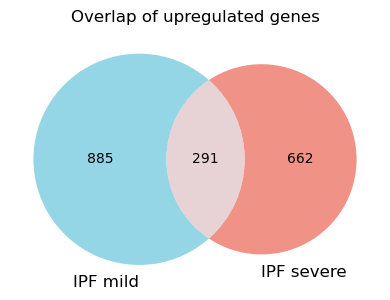

Overlap genes: 291
['ABCC1', 'ABHD17C', 'ABRACL', 'AC000050.1', 'AC022150.4', 'AC025946.1', 'AC026356.2', 'AC093157.1', 'ACACA', 'ADAM15', 'ADAM19', 'ADAMTS6', 'ADAMTS9', 'ADCY4', 'AF165147.1', 'AGAP3', 'AHR', 'AIF1L', 'AKAP13', 'AL031595.3', 'AL159156.1', 'AL161891.1', 'AL353586.1', 'AL590226.1', 'ALG5', 'ANGEL1', 'ANTXR1', 'AP1G2', 'AP1S2', 'AP2M1', 'AP3M1', 'AP3M2', 'AQP1', 'ARAP3', 'ARFGEF3', 'ARHGAP15', 'ARHGAP31', 'ARHGEF28', 'ASRGL1', 'ASS1', 'ATF1', 'ATF7IP2', 'ATG4A', 'ATP11A', 'ATP13A3', 'ATP5PB', 'BCR', 'BMPER', 'C8orf37-AS1', 'CANX', 'CASKIN2', 'CCDC3', 'CD109', 'CDC40', 'CDK17', 'CDYL2', 'CFAP161', 'CHURC1', 'CIAO2A', 'CLEC14A', 'CLTB', 'COPG1', 'CPNE5', 'CPNE8', 'CREM', 'CROCC', 'CTIF', 'CXCL12', 'DGKZ', 'DHH', 'DISP1', 'DKK2', 'DVL3', 'ECE1', 'EIF2B1', 'EIF3L', 'ELK3', 'ELMO2', 'ELMSAN1', 'ELOVL5', 'EMP1', 'ENG', 'EPB41L4A', 'EPHB4', 'ERC1', 'ERCC8', 'ESAM', 'ETV6', 'EVI5', 'EXOC6', 'EXOG', 'EYA3', 'FAM214B', 'FAM221A', 'FAT4', 'FBXO10', 'FBXO38', 'FCN3', 'FDPS', 'FENDRR

In [32]:
from matplotlib_venn import venn2
mild_up = set(glist_mild_up)
severe_up = set(glist_severe_up)

overlap_genes = mild_up & severe_up

plt.figure(figsize=(4, 4))

venn2(
    [mild_up, severe_up],
    set_labels=("IPF mild", "IPF severe"),
    set_colors=("#4DBBD5", "#E64B35"),
    alpha=0.6,
)

plt.title("Overlap of upregulated genes")
plt.tight_layout()
plt.show()

print(f"Overlap genes: {len(overlap_genes)}")
print(sorted(overlap_genes))